### **Description**

Recipe showing how to construct a NEMODataTree from UKESM1-0-LL CMIP6 NEMO ocean component outputs publicly available via AWS S3 Open Data Registry.

For more details on the UKESM1 Earth System Model configuration, users should see Sellar et al. (2019) [here](https://doi.org/10.1029/2019MS001739).

---
### **Background**

In addition to ocean-only and ocean sea-ice hindcast simulations (prescribing surface atmospheric forcing), NEMO models are also used as the ocean components in many coupled climate models, including the UK Earth System Model (UKESM) developed jointly by the UK Met Office and Natural Environment Research Council (NERC).

Here, we show how to construct a `NEMODataTree` from the 1° global ocean sea-ice component of [UKESM1-0-LL](https://doi.org/10.1029/2019MS001739) included in the sixth Coupled Model Intercomparsion Project ([CMIP6](https://wcrp-cmip.org/cmip-phases/cmip6/)) using outputs accessible via the [AWS Open Data Registry](https://registry.opendata.aws/cmip6/).

Since CMIP6 outputs are processed and formatted according to the CMIP Community Climate Model Output Rewriter (CMOR) software, we will include several additional pre-processing steps to reformat our NEMO model outputs in order to construct a `NEMODataTree`

**Important: Only CMIP ocean model output variables stored on their original NEMO ocean model grid (i.e, `gn`) can be used to construct a `NEMODataTree`.**

---

In [1]:
# -- Import required packages -- #
import matplotlib.pyplot as plt
import xarray as xr

from nemo_cookbook import NEMODataTree

xr.set_options(display_style="text")

### **Using Dask**

**Optional: Connect Client to Dask Local Cluster to run analysis in parallel.**

Note that, although using Dask is not strictly necessary for this simple example using UKESM1-0-LL, if we wanted to generalise this recipe to HadGEM3-GC31-HH outputs, using Dask would be essential to avoid unnecessary slow calculations using only a single process.

In [ ]:
# -- Initialise Dask Local Cluster -- #
import dask
from dask.distributed import Client, LocalCluster

# Update temporary directory for Dask workers:
dask.config.set({'temporary_directory': '/dssgfs01/working/otooth/Diagnostics/nemo_cookbook/recipes/',
                 'local_directory': '/dssgfs01/working/otooth/Diagnostics/nemo_cookbook/recipes/'
                 })

# Create Local Cluster:
cluster = LocalCluster(n_workers=5, threads_per_worker=2, memory_limit='8GB')
client = Client(cluster)
client

### **Accessing UKESM1-0-LL Model Data**
**Let's begin by loading the domain variables for our UKESM1-0-LL NEMO model from the [JASMIN Object Store](https://help.jasmin.ac.uk/docs/short-term-project-storage/using-the-jasmin-object-store/)**. 

**Alternatively, you can replace the ``domain_filepath`` below with a file path to your domain_cfg.nc file and read this with xarray's ``open_dataset()`` function.**

In [2]:
# Define directory path to ancillary files:
domain_url = "https://noc-msm-o.s3-ext.jc.rl.ac.uk/nemo-cookbook/ukesm1/domain_cfg"

# Open eORCA1 NEMO model domain_cfg:
ds_domain = xr.open_zarr(domain_url, consolidated=True, chunks={})

ds_domain

<xarray.Dataset> Size: 488MB
Dimensions:       (y: 330, x: 360, nav_lev: 75)
Dimensions without coordinates: y, x, nav_lev
Data variables: (12/47)
    bathy         (y, x) float32 475kB dask.array<chunksize=(330, 360), meta=np.ndarray>
    e1f           (y, x) float64 950kB dask.array<chunksize=(330, 360), meta=np.ndarray>
    e1t           (y, x) float64 950kB dask.array<chunksize=(330, 360), meta=np.ndarray>
    e1u           (y, x) float64 950kB dask.array<chunksize=(330, 360), meta=np.ndarray>
    e1v           (y, x) float64 950kB dask.array<chunksize=(330, 360), meta=np.ndarray>
    e2f           (y, x) float64 950kB dask.array<chunksize=(330, 360), meta=np.ndarray>
    ...            ...
    umask         (nav_lev, y, x) int8 9MB dask.array<chunksize=(25, 330, 360), meta=np.ndarray>
    umaskutil     (y, x) int8 119kB dask.array<chunksize=(330, 360), meta=np.ndarray>
    vmask         (nav_lev, y, x) int8 9MB dask.array<chunksize=(25, 330, 360), meta=np.ndarray>
    vmaskutil     (y, x) int8 119kB dask.array<chunksize=(330, 360), meta=np.ndarray>
    wmask         (nav_lev, y, x) int8 9MB dask.array<chunksize=(25, 330, 360), meta=np.ndarray>
    wmaskutil     (y, x) int8 119kB dask.array<chunksize=(330, 360), meta=np.ndarray>
Attributes:
    file_name:  mesh_mask.nc
    TimeStamp:  06/02/2026 10:14:02 +0000

**Next, we need to open the conservative temperature and vertical grid cell scale factor variables stored at T-points as a single dataset.**

**Given that CMIP6 data are distributed as individual variables rather than a consolidated dataset of scalar variables, we must first merge the chosen variables into a single gridT dataset.**

In [3]:
# Define base URL and storage options to access CMIP6 data from S3:
base_url = "s3://cmip6-pds/CMIP6/CMIP/MOHC/UKESM1-0-LL/esm-hist/r1i1p1f2/Omon"
storage_options = {"anon": True}

# Open conservative temperature (deg C), vertical grid cell thicknesses (m), and sea surface height (m) variables from Zarr v2 stores:
ds_thetao = xr.open_zarr(f"{base_url}/thetao/gn/v20190723", storage_options=storage_options, zarr_format=2)
ds_thkcello = xr.open_zarr(f"{base_url}/thkcello/gn/v20190723", storage_options=storage_options, zarr_format=2)
ds_zos = xr.open_zarr(f"{base_url}/zos/gn/v20190723", storage_options=storage_options, zarr_format=2)

# Construct single NEMO model T-grid dataset:
ds_gridT = xr.merge([ds_thetao, ds_thkcello, ds_zos], compat="override", join='override')

# Update dimension names and rename thkcello -> e3t:
ds_gridT = ds_gridT.rename({"time": "time_counter",
                            "lev": "deptht",
                            "j": "y",
                            "i": "x",
                            "thkcello": "e3t"
                            })
ds_gridT

<xarray.Dataset> Size: 142GB
Dimensions:             (time_counter: 1980, deptht: 75, y: 330, x: 360,
                         vertices: 4, bnds: 2)
Coordinates:
  * time_counter        (time_counter) object 16kB 1850-01-16 00:00:00 ... 20...
  * deptht              (deptht) float64 600B 0.5058 1.556 ... 5.902e+03
  * y                   (y) int32 1kB 0 1 2 3 4 5 6 ... 324 325 326 327 328 329
  * x                   (x) int32 1kB 0 1 2 3 4 5 6 ... 354 355 356 357 358 359
    latitude            (y, x) float32 475kB dask.array<chunksize=(330, 360), meta=np.ndarray>
    longitude           (y, x) float32 475kB dask.array<chunksize=(330, 360), meta=np.ndarray>
    lev_bnds            (deptht, bnds) float64 1kB dask.array<chunksize=(75, 2), meta=np.ndarray>
    time_bnds           (time_counter, bnds) object 32kB dask.array<chunksize=(1980, 2), meta=np.ndarray>
Dimensions without coordinates: vertices, bnds
Data variables:
    thetao              (time_counter, deptht, y, x) float32 71GB dask.array<chunksize=(4, 75, 330, 360), meta=np.ndarray>
    vertices_latitude   (y, x, vertices) float32 2MB dask.array<chunksize=(330, 360, 4), meta=np.ndarray>
    vertices_longitude  (y, x, vertices) float32 2MB dask.array<chunksize=(330, 360, 4), meta=np.ndarray>
    e3t                 (time_counter, deptht, y, x) float32 71GB dask.array<chunksize=(6, 75, 330, 360), meta=np.ndarray>
    zos                 (time_counter, y, x) float32 941MB dask.array<chunksize=(242, 330, 360), meta=np.ndarray>
Attributes: (12/47)
    Conventions:            CF-1.7 CMIP-6.2
    activity_id:            CMIP
    branch_method:          standard
    branch_time_in_child:   0.0
    branch_time_in_parent:  0.0
    cmor_version:           3.4.0
    ...                     ...
    table_id:               Omon
    table_info:             Creation Date:(13 December 2018) MD5:2b12b5db6db1...
    title:                  UKESM1-0-LL output prepared for CMIP6
    tracking_id:            hdl:21.14100/262570a1-6ce8-4a2f-b673-054cae1cd25f...
    variable_id:            thetao
    variant_label:          r1i1p1f2

**Next, we need to create a `gridV` dataset from the meridional velocities stored at V-points:.**

In [4]:
# Open meridional velocity variable (m/s) from Zarr v2 stores:
ds_gridV = xr.open_zarr(f"{base_url}/vo/gn/v20190723", storage_options=storage_options, zarr_format=2)

# Update dimension names and thkcello -> e3t:
ds_gridV = ds_gridV.rename({"time": "time_counter",
                            "lev": "depthv",
                            "j": "y",
                            "i": "x",
                            })
ds_gridV

<xarray.Dataset> Size: 71GB
Dimensions:             (y: 330, x: 360, vertices: 4, time_counter: 1980,
                         depthv: 75, bnds: 2)
Coordinates:
  * y                   (y) int32 1kB 0 1 2 3 4 5 6 ... 324 325 326 327 328 329
  * x                   (x) int32 1kB 0 1 2 3 4 5 6 ... 354 355 356 357 358 359
    latitude            (y, x) float32 475kB dask.array<chunksize=(330, 360), meta=np.ndarray>
    longitude           (y, x) float32 475kB dask.array<chunksize=(330, 360), meta=np.ndarray>
  * time_counter        (time_counter) object 16kB 1850-01-16 00:00:00 ... 20...
  * depthv              (depthv) float64 600B 0.5058 1.556 ... 5.902e+03
    lev_bnds            (depthv, bnds) float64 1kB dask.array<chunksize=(75, 2), meta=np.ndarray>
    time_bnds           (time_counter, bnds) object 32kB dask.array<chunksize=(1980, 2), meta=np.ndarray>
Dimensions without coordinates: vertices, bnds
Data variables:
    vertices_latitude   (y, x, vertices) float32 2MB dask.array<chunksize=(330, 360, 4), meta=np.ndarray>
    vertices_longitude  (y, x, vertices) float32 2MB dask.array<chunksize=(330, 360, 4), meta=np.ndarray>
    vo                  (time_counter, depthv, y, x) float32 71GB dask.array<chunksize=(3, 75, 330, 360), meta=np.ndarray>
Attributes: (12/46)
    Conventions:            CF-1.7 CMIP-6.2
    activity_id:            CMIP
    branch_method:          standard
    branch_time_in_child:   0.0
    branch_time_in_parent:  0.0
    cmor_version:           3.4.0
    ...                     ...
    table_id:               Omon
    table_info:             Creation Date:(13 December 2018) MD5:2b12b5db6db1...
    title:                  UKESM1-0-LL output prepared for CMIP6
    tracking_id:            hdl:21.14100/e288b332-98a6-46b5-8593-d09de22ea7ac...
    variable_id:            vo
    variant_label:          r1i1p1f2

### **Creating a NEMODataTree**

**Next, let's create a NEMODataTree to store our domain and T & V-grid variables for the UKESM1-0-LL ocean component between 2004-2015.**

**Here, we use `vco_ref=True` to add the reference vertical scale factors `e3{t/u/v/f/w}_0` and water column heights `h{t/u/v/f/w}_0` to our NEMODataTree:**

In [ ]:
# Define dictionary of grid datasets defining UKESM1-0-LL (eORCA1) parent model domain with no child/grand-child nests:
datasets = {"parent":
            {"domain": ds_domain,
             "gridT": ds_gridT.sel(time_counter=slice("2004-01", "2014-12")),
             "gridV": ds_gridV.sel(time_counter=slice("2004-01", "2014-12")),
             }
            }

# Initialise a new NEMODataTree whose parent domain is zonally periodic, north-folding on F-points including reference
# vertical scale factors and water column heights:
nemo = NEMODataTree.from_datasets(datasets=datasets, iperio=True, nftype="F", read_mask=True, vco_ref=True, name="UKESM1-0-LL")

nemo

<xarray.DataTree 'UKESM1-0-LL'>
Group: /
│   Dimensions:       (time_counter: 132, bnds: 2)
│   Coordinates:
│     * time_counter  (time_counter) object 1kB 2004-01-16 00:00:00 ... 2014-12-1...
│       time_bnds     (time_counter, bnds) object 2kB dask.array<chunksize=(132, 2), meta=np.ndarray>
│   Dimensions without coordinates: bnds
│   Attributes:
│       nftype:   F
│       iperio:   True
├── Group: /gridT
│       Dimensions:             (time_counter: 132, k: 75, j: 330, i: 360, vertices: 4,
│                                bnds: 2)
│       Coordinates:
│         * k                   (k) int64 600B 1 2 3 4 5 6 7 8 ... 69 70 71 72 73 74 75
│         * deptht              (k) float64 600B 0.5058 1.556 ... 5.698e+03 5.902e+03
│         * j                   (j) int64 3kB 1 2 3 4 5 6 7 ... 325 326 327 328 329 330
│         * i                   (i) int64 3kB 1 2 3 4 5 6 7 ... 355 356 357 358 359 360
│           latitude            (j, i) float32 475kB dask.array<chunksize=(330, 360), meta=np.ndarray>
│           longitude           (j, i) float32 475kB dask.array<chunksize=(330, 360), meta=np.ndarray>
│           gphit               (j, i) float32 475kB dask.array<chunksize=(330, 360), meta=np.ndarray>
│           glamt               (j, i) float32 475kB dask.array<chunksize=(330, 360), meta=np.ndarray>
│           lev_bnds            (k, bnds) float64 1kB dask.array<chunksize=(75, 2), meta=np.ndarray>
│           time_bnds           (time_counter, bnds) object 2kB dask.array<chunksize=(132, 2), meta=np.ndarray>
│       Dimensions without coordinates: vertices, bnds
│       Data variables:
│           thetao              (time_counter, k, j, i) float32 5GB dask.array<chunksize=(4, 75, 330, 360), meta=np.ndarray>
│           vertices_latitude   (j, i, vertices) float32 2MB dask.array<chunksize=(330, 360, 4), meta=np.ndarray>
│           vertices_longitude  (j, i, vertices) float32 2MB dask.array<chunksize=(330, 360, 4), meta=np.ndarray>
│           e3t                 (time_counter, k, j, i) float32 5GB dask.array<chunksize=(6, 75, 330, 360), meta=np.ndarray>
│           zos                 (time_counter, j, i) float32 63MB dask.array<chunksize=(88, 330, 360), meta=np.ndarray>
│           e1t                 (j, i) float64 950kB dask.array<chunksize=(330, 360), meta=np.ndarray>
│           e2t                 (j, i) float64 950kB dask.array<chunksize=(330, 360), meta=np.ndarray>
│           tmask               (k, j, i) int8 9MB dask.array<chunksize=(25, 330, 360), meta=np.ndarray>
│           tmaskutil           (j, i) int8 119kB dask.array<chunksize=(330, 360), meta=np.ndarray>
│           e3t_0               (k, j, i) float64 71MB dask.array<chunksize=(25, 330, 360), meta=np.ndarray>
│           ht_0                (j, i) float64 950kB dask.array<chunksize=(330, 360), meta=np.ndarray>
│       Attributes: (12/49)
│           Conventions:            CF-1.7 CMIP-6.2
│           activity_id:            CMIP
│           branch_method:          standard
│           branch_time_in_child:   0.0
│           branch_time_in_parent:  0.0
│           cmor_version:           3.4.0
│           ...                     ...
│           title:                  UKESM1-0-LL output prepared for CMIP6
│           tracking_id:            hdl:21.14100/262570a1-6ce8-4a2f-b673-054cae1cd25f...
│           variable_id:            thetao
│           variant_label:          r1i1p1f2
│           nftype:                 F
│           iperio:                 True
├── Group: /gridU
│       Dimensions:       (j: 330, i: 360, k: 75)
│       Coordinates:
│         * j             (j) int64 3kB 1 2 3 4 5 6 7 8 ... 324 325 326 327 328 329 330
│         * i             (i) float64 3kB 1.5 2.5 3.5 4.5 ... 357.5 358.5 359.5 360.5
│           gphiu         (j, i) float32 475kB dask.array<chunksize=(330, 360), meta=np.ndarray>
│           glamu         (j, i) float32 475kB dask.array<chunksize=(330, 360), meta=np.ndarray>
│         * k             (k) int64 600B 1 2 

### **Preparing Vertical Grid Scale Factors**

**One challenge when working with CMIP6 datasets can be the absence of vertical grid scale factors located at NEMO model V-points in CMORISED outputs.**

**Next, let's add vertical grid scale factors to our NEMODataTree `gridV` nodes following the vertical coordinate substitution approach of NEMO itself:**

$$e_{3v}(i, j, k, t) = e_{3v\_0}(i, j, k)(1 + r_{3v}(i, j, t)*vmask(i, j, k))$$

where $r_{3v}$ is the ratio of the sea surface height $\eta$ to the reference water column height $h_{v\_0}$:

$$r_{3v}(i, j, t) = \frac{\eta(i, j, t)}{h_{v\_0}(i, j)}$$


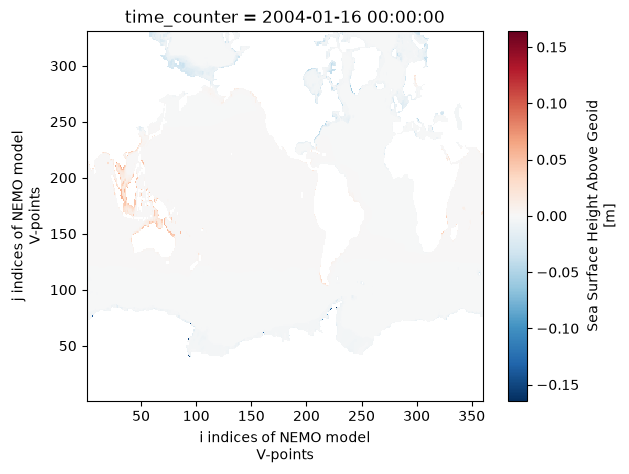

In [6]:
# Linearly interpolate sea surface height (zos) onto V-grid points:
nemo['gridV/zos'] = nemo['gridT/zos'].interp_to(to="V")

# Define the ratio of sea surface height (zos) to water column height (hv_0) on V-grid points:
nemo['gridV/r3v'] = (nemo['gridV/zos'] / nemo['gridV/hv_0']).masked

# Plot example ratio of sea surface height to water column height on V-grid points:
nemo['gridV/r3v'].isel(time_counter=0).plot()

In [7]:
# Define the time-evolving vertical grid cell thicknesses (m) on V-grid points:
nemo["gridV/e3v"] = (nemo['gridV/e3v_0'].masked * (1 + nemo['gridV/r3v'])).transpose("time_counter", "k", "j", "i")

nemo["gridV/e3v"]

<NEMODataTree 'UKESM1-0-LL'>
  <NEMODataArray 'e3v' (Domain: '.', Grid: 'gridV', Grid Type: 'V')>

<xarray.DataArray 'e3v' (time_counter: 132, k: 75, j: 330, i: 360)> Size: 9GB
dask.array<transpose, shape=(132, 75, 330, 360), dtype=float64, chunksize=(88, 25, 330, 360), chunktype=numpy.ndarray>
Coordinates:
  * time_counter  (time_counter) object 1kB 2004-01-16 00:00:00 ... 2014-12-1...
  * k             (k) int64 600B 1 2 3 4 5 6 7 8 9 ... 68 69 70 71 72 73 74 75
  * depthv        (k) float64 600B 0.5058 1.556 2.668 ... 5.698e+03 5.902e+03
  * j             (j) float64 3kB 1.5 2.5 3.5 4.5 ... 327.5 328.5 329.5 330.5
  * i             (i) int64 3kB 1 2 3 4 5 6 7 8 ... 354 355 356 357 358 359 360
    latitude      (j, i) float32 475kB dask.array<chunksize=(330, 360), meta=np.ndarray>
    longitude     (j, i) float32 475kB dask.array<chunksize=(330, 360), meta=np.ndarray>
    gphiv         (j, i) float32 475kB dask.array<chunksize=(330, 360), meta=np.ndarray>
    glamv         (j, i) float32 475kB dask.array<chunksize=(330, 360), meta=np.ndarray>
Attributes:
    cell_measures:  area: areacello
    cell_methods:   area: mean where sea time: mean
    comment:        This is the dynamic sea level, so should have zero global...
    long_name:      Sea Surface Height Above Geoid
    original_name:  mo: (variable_name: zos)
    standard_name:  sea_surface_height_above_geoid
    units:          m

### **Extracting the RAPID-MOCHA array as a zonal hydrographic section**

**Now, let's extract an approximately zonal section at the latitude of the RAPID-MOCHA array from our NEMODataTree.**

**The resulting hydrographic section will be defined on the NEMO model V-grid at the constant j-coordinate whose average latitude is closest to 26.5°N.**

**We need to provide the names of any scalar variables (e.g., `scalar_vars=['thetao', 'so']`) to be linearly interpolated onto the V-grid.**

In [8]:
# Extract the RAPID-MOCHA array from the UKESM1-0-LL ocean model data:
ds_rapid = nemo.extract_zonal_section(lat=26.5,
                                      lon_min=-82.0,
                                      lon_max=-10.0,
                                      u_vars=None,
                                      scalar_vars=['thetao'],
                                      dom='.'
                                      )

ds_rapid

<xarray.Dataset> Size: 14MB
Dimensions:             (bdy: 72, vertices: 4, time_counter: 132, k: 75, bnds: 2)
Coordinates:
    latitude            (bdy) float32 288B dask.array<chunksize=(72,), meta=np.ndarray>
    longitude           (bdy) float32 288B dask.array<chunksize=(72,), meta=np.ndarray>
  * i                   (bdy) int64 576B 206 207 208 209 210 ... 274 275 276 277
    gphib               (bdy) float32 288B dask.array<chunksize=(72,), meta=np.ndarray>
    glamb               (bdy) float32 288B dask.array<chunksize=(72,), meta=np.ndarray>
  * time_counter        (time_counter) object 1kB 2004-01-16 00:00:00 ... 201...
  * k                   (k) int64 600B 1 2 3 4 5 6 7 8 ... 69 70 71 72 73 74 75
  * depthb              (k) float64 600B 0.5058 1.556 ... 5.698e+03 5.902e+03
    lev_bnds            (k, bnds) float64 1kB dask.array<chunksize=(75, 2), meta=np.ndarray>
    time_bnds           (time_counter, bnds) object 2kB dask.array<chunksize=(132, 2), meta=np.ndarray>
    j                   float64 8B 228.5
Dimensions without coordinates: bdy, vertices, bnds
Data variables: (12/15)
    vertices_latitude   (bdy, vertices) float32 1kB dask.array<chunksize=(72, 4), meta=np.ndarray>
    vertices_longitude  (bdy, vertices) float32 1kB dask.array<chunksize=(72, 4), meta=np.ndarray>
    vo                  (time_counter, k, bdy) float32 3MB dask.array<chunksize=(3, 25, 72), meta=np.ndarray>
    e1b                 (bdy) float64 576B dask.array<chunksize=(72,), meta=np.ndarray>
    e2b                 (bdy) float64 576B dask.array<chunksize=(72,), meta=np.ndarray>
    bmask               (k, bdy) int8 5kB dask.array<chunksize=(25, 72), meta=np.ndarray>
    ...                  ...
    zos                 (time_counter, bdy) float64 76kB dask.array<chunksize=(88, 72), meta=np.ndarray>
    r3v                 (time_counter, bdy) float64 76kB dask.array<chunksize=(88, 72), meta=np.ndarray>
    e3b                 (time_counter, k, bdy) float64 6MB dask.array<chunksize=(88, 25, 72), meta=np.ndarray>
    thetao              (time_counter, k, bdy) float64 6MB dask.array<chunksize=(4, 25, 72), meta=np.ndarray>
    i_bdy               (bdy) int64 576B 206 207 208 209 210 ... 274 275 276 277
    j_bdy               (bdy) float64 576B 228.5 228.5 228.5 ... 228.5 228.5
Attributes: (12/46)
    Conventions:            CF-1.7 CMIP-6.2
    activity_id:            CMIP
    branch_method:          standard
    branch_time_in_child:   0.0
    branch_time_in_parent:  0.0
    cmor_version:           3.4.0
    ...                     ...
    table_id:               Omon
    table_info:             Creation Date:(13 December 2018) MD5:2b12b5db6db1...
    title:                  UKESM1-0-LL output prepared for CMIP6
    tracking_id:            hdl:21.14100/e288b332-98a6-46b5-8593-d09de22ea7ac...
    variable_id:            vo
    variant_label:          r1i1p1f2

**Next, let's calculate the AMOC strength as the maximum of the vertical overturning stream function by approximating the vertical coordinate $k$ coordinates for depth coordinates.**

In [9]:
# Calculate volume transport = seawater velocity x grid cell face area [m3/s]:
ds_rapid['vto'] = ds_rapid['vo'] * ds_rapid['e3b'] * ds_rapid['e1b']

# Calculate meridional overturning circulation (MOC) streamfunction [Sv]:
ds_rapid['moc_k'] = 1E-6 * ds_rapid['vto'].sum(dim=['bdy']).cumsum(dim='k')

ds_rapid

<xarray.Dataset> Size: 20MB
Dimensions:             (bdy: 72, vertices: 4, time_counter: 132, k: 75, bnds: 2)
Coordinates:
    latitude            (bdy) float32 288B dask.array<chunksize=(72,), meta=np.ndarray>
    longitude           (bdy) float32 288B dask.array<chunksize=(72,), meta=np.ndarray>
  * i                   (bdy) int64 576B 206 207 208 209 210 ... 274 275 276 277
    gphib               (bdy) float32 288B dask.array<chunksize=(72,), meta=np.ndarray>
    glamb               (bdy) float32 288B dask.array<chunksize=(72,), meta=np.ndarray>
  * time_counter        (time_counter) object 1kB 2004-01-16 00:00:00 ... 201...
  * k                   (k) int64 600B 1 2 3 4 5 6 7 8 ... 69 70 71 72 73 74 75
  * depthb              (k) float64 600B 0.5058 1.556 ... 5.698e+03 5.902e+03
    lev_bnds            (k, bnds) float64 1kB dask.array<chunksize=(75, 2), meta=np.ndarray>
    time_bnds           (time_counter, bnds) object 2kB dask.array<chunksize=(132, 2), meta=np.ndarray>
    j                   float64 8B 228.5
Dimensions without coordinates: bdy, vertices, bnds
Data variables: (12/17)
    vertices_latitude   (bdy, vertices) float32 1kB dask.array<chunksize=(72, 4), meta=np.ndarray>
    vertices_longitude  (bdy, vertices) float32 1kB dask.array<chunksize=(72, 4), meta=np.ndarray>
    vo                  (time_counter, k, bdy) float32 3MB dask.array<chunksize=(3, 25, 72), meta=np.ndarray>
    e1b                 (bdy) float64 576B dask.array<chunksize=(72,), meta=np.ndarray>
    e2b                 (bdy) float64 576B dask.array<chunksize=(72,), meta=np.ndarray>
    bmask               (k, bdy) int8 5kB dask.array<chunksize=(25, 72), meta=np.ndarray>
    ...                  ...
    e3b                 (time_counter, k, bdy) float64 6MB dask.array<chunksize=(88, 25, 72), meta=np.ndarray>
    thetao              (time_counter, k, bdy) float64 6MB dask.array<chunksize=(4, 25, 72), meta=np.ndarray>
    i_bdy               (bdy) int64 576B 206 207 208 209 210 ... 274 275 276 277
    j_bdy               (bdy) float64 576B 228.5 228.5 228.5 ... 228.5 228.5
    vto                 (time_counter, k, bdy) float64 6MB dask.array<chunksize=(3, 25, 72), meta=np.ndarray>
    moc_k               (time_counter, k) float64 79kB dask.array<chunksize=(3, 25), meta=np.ndarray>
Attributes: (12/46)
    Conventions:            CF-1.7 CMIP-6.2
    activity_id:            CMIP
    branch_method:          standard
    branch_time_in_child:   0.0
    branch_time_in_parent:  0.0
    cmor_version:           3.4.0
    ...                     ...
    table_id:               Omon
    table_info:             Creation Date:(13 December 2018) MD5:2b12b5db6db1...
    title:                  UKESM1-0-LL output prepared for CMIP6
    tracking_id:            hdl:21.14100/e288b332-98a6-46b5-8593-d09de22ea7ac...
    variable_id:            vo
    variant_label:          r1i1p1f2

### **Visualising the historical vertical overturning strength**

**Finally, let's visualise the results by plotting the time-series of the maximum of the RAPID-MOCHA vertical overturning stream function:**

Text(0, 0.5, 'Max($\\Psi_{z}$) [Sv]')

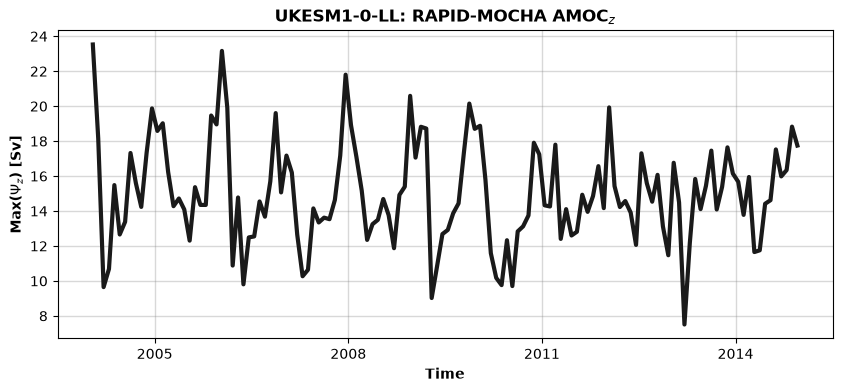

In [10]:
# Plot time-mean diapycnal overturning stream functions along the OSNAP section:
plt.figure(figsize=(10, 4))
plt.grid(True, lw=1, color='0.5', alpha=0.3)

# Plot RAPID-MOCHA Total vertical overturning stream function:
ds_rapid['moc_k'].max(dim="k").plot(lw=3, color='0.1')

# Axes labels:
plt.title("UKESM1-0-LL: RAPID-MOCHA AMOC$_{z}$", fontdict={"size": 12, "weight": "bold"})
plt.xlabel("Time", fontdict={"size": 10, "weight": "bold"})
plt.ylabel("Max($\\Psi_{z}$) [Sv]", fontdict={"size": 10, "weight": "bold"})